# **Project Introduction**

Traffic safety is a compelling domain because the consequences are concrete and high-stakes. Such project could inform smarter street lighting investments, targeted road improvements, or real-time driver alerts.

This project uses the Maryland Crash Reporting dataset, sourced from Kaggle, which contains 32,115 crash records collected across Maryland counties. Each record captures conditions at the time of the crash, including lighting, weather, road conditions, collision type, and the primary harm event along with the official report classification assigned by law enforcement. The prediction goal is to estimate crash severity using these environmental and situational features.

The features are all categorical and label-encoded, which forces the models to treat nominal categories as if they have an implicit numeric order. Moreover, fatal crashes represent a very small fraction of total records, creating a class imbalance that pulls the models toward predicting the majority class.

#**Crash analysis**

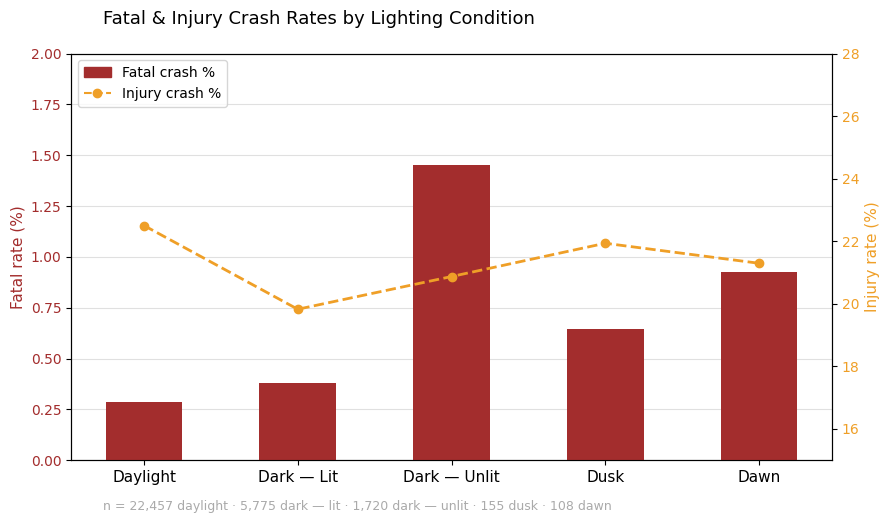

This dual-axis visualization offers a critical look at how lighting conditions influence collision severity. While injury rates remain relatively stable across all conditions, the fatality rate is highly sensitive to visibility. Specifically, crashes occurring in "Dark — Unlit" conditions exhibit a fatality rate of approximately 1.45%, which is nearly five times higher than the 0.29% observed during daylight. This suggest that while lighting may not significantly change the likelihood of an injury occurring once a crash happens, it drastically increases the lethality of those incidents.



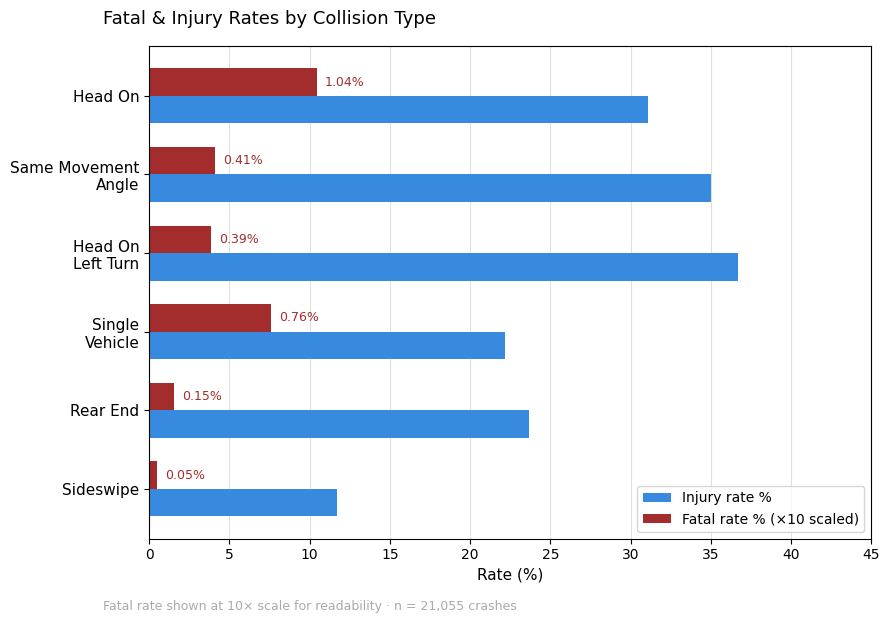

The comparative analysis of collision types reveals that Head On collisions are the most high-stakes category, exhibiting the highest fatality rate (1.04%) despite not having the highest injury frequency. This category demonstrates a unique profile where the ratio of fatalities to injuries is significantly higher than any other group. Conversely, while Head On Left Turn and Same Movement Angle collisions show higher total injury rates (peaking at approximately 37%), their fatality rates are substantially lower (0.39% and 0.41%, respectively). This suggests that these collision types are more likely to result in non-lethal property damage or personal injury, likely due to lower impact speeds or different vehicle dynamics compared to direct head-on impacts.



# **Decision tree analysis**

Depth  |    Train R²  |  Test R²  |  Train RMSE  |  Test RMSE
--------------------------------------------------------
3      |      0.0611  |   0.0599    |   0.4074    |   0.4066

7      |      0.1014  |   0.0923    |   0.3986    |   0.3995

Since there is no numeric column in this dataset, crash severity is encoded as an ordinal: 0 = Property Damage, 1 = Injury, 2 = Fatal. The regressor predicts a continuous score in that range. Values closer to 2 signal higher predicted severity.

The very first split the tree makes on whichever feature best separates the three severity levels across all 32,115 rows is the root node. In this data that's almost certainly harm_event_desc1 , since hitting a pedestrian vs. a parked car carries vastly different severity profiles.

**One important split**

the model creates a second-level branch using the collision_type_descvariable to categorize incidents. By grouping "Head-On" and "Single-Vehicle" crashes together, the model isolates high-energy events that carry significantly higher fatality risks—recorded at 1.04% and 0.76% respectively. Conversely, the lower branch of this split filters out "Rear-End" and "Sideswipe" crashes, which are statistically much safer outcomes.

**Example prediction path**

A crash with harm_event_desc1 = Parked Vehicle → collision_type = Same Direction → light_desc = Daylight would follow the low-severity branch at each split and land at a predicted score near 0.05 (essentially property damage).

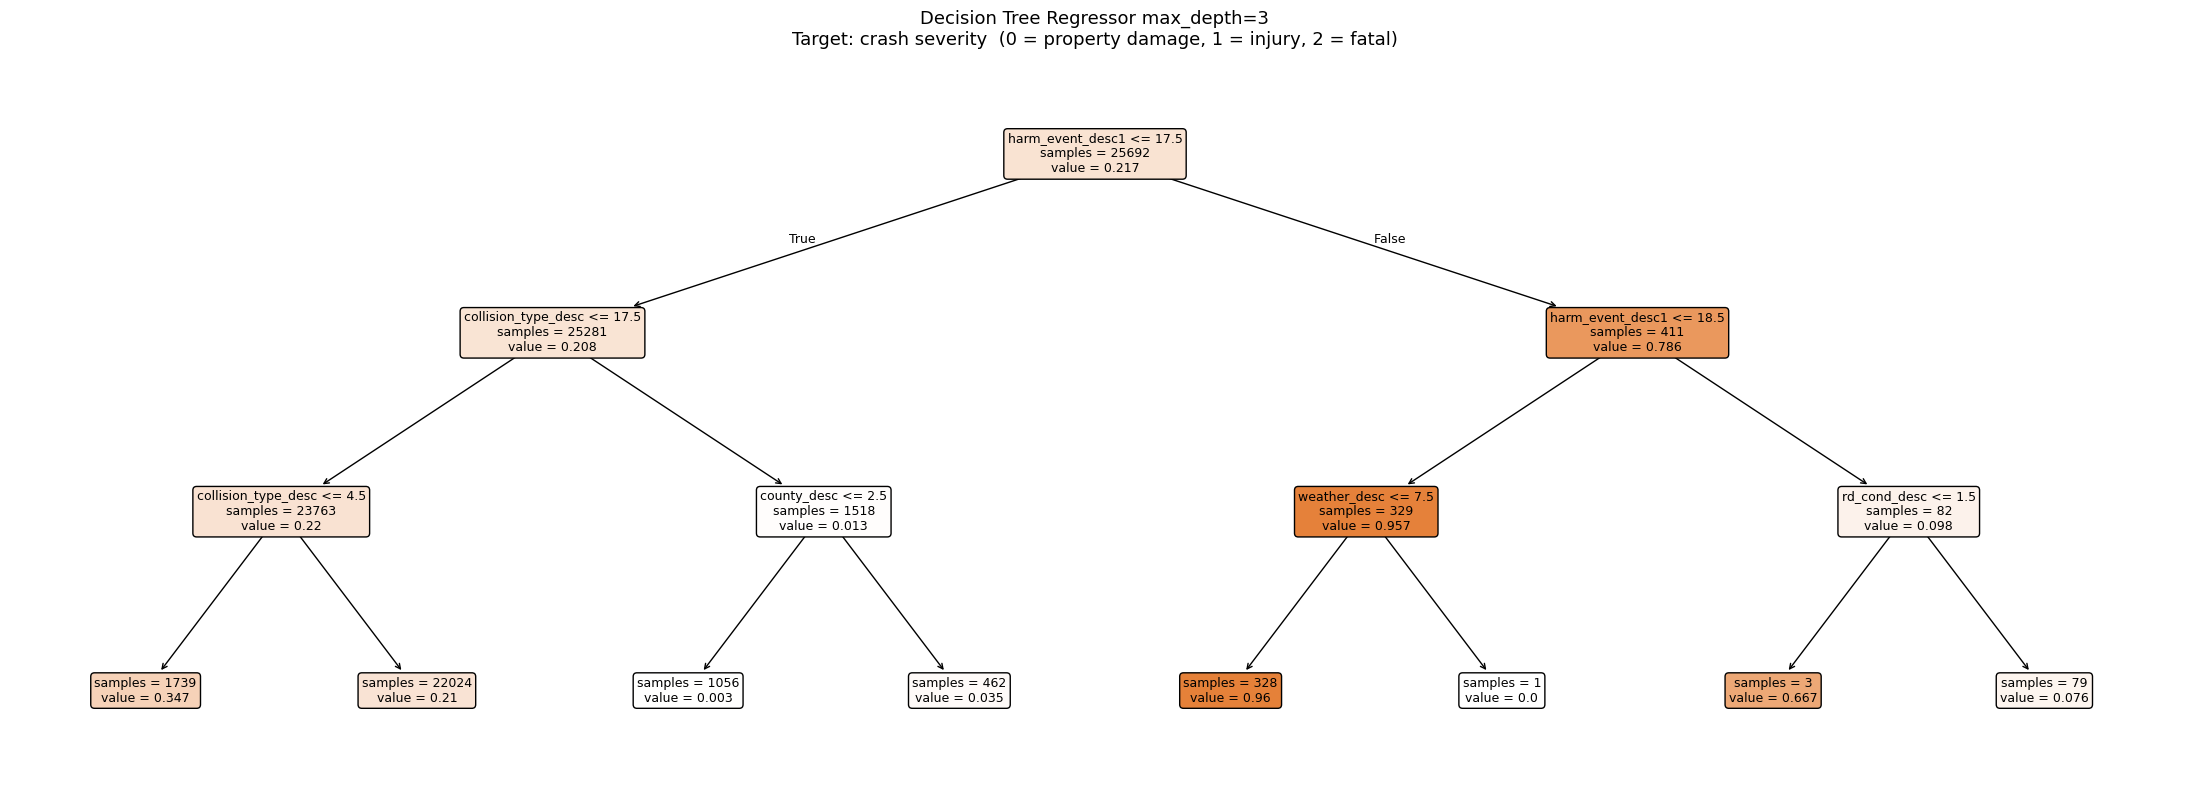

#**Random forest model**

Train R²  : 0.1086

Test  R²  : 0.1041

Train RMSE: 0.3970

Test  RMSE: 0.3969

To further investigate the dataset's predictability and establish a comparative baseline against the Decision tree model, a standalone Random Forest Regressor was evaluated, and the above metrics were used to evaluate the model.

The R² metric indicates on the test set, the model explains approximately 10.4% of the variance. The marginal difference of 0.0045 between the training and testing scores is highly informative: it demonstrates that the model is not overfitting . However, the exceptionally low overall magnitude of the R² score points to a state of high bias.

The near-identical values ​across both the training and testing subsets validate the conclusion that the model's performance is remarkably consistent. It is generalizing what it has learned perfectly, without memorizing noise in the training data.

#**Random forest' Feature importance**

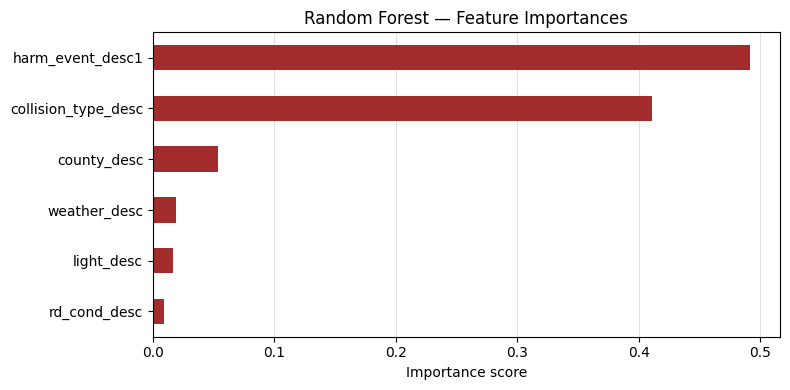

The model's predictive capability is dictated by harm_event_desc1(Importance Score: ~0.49) and collision_type_desc(Importance Score: ~0.41). Together, these two incident descriptors account for approximately 90% of the model's decision-making weight.

Geographic and environmental variables demonstrate negligible predictive power. county_desc provides a very weak signal (~~ 0.05), while weather_desc(~~ 0.02), light_desc(~~ 0.015), and rd_cond_desc(~~ 0.01) fail to influence the model's output in any statistically meaningful way.

# **Gradient Boosting**

The Gradient Boosting model was implemented as an alternative ensemble approach to determine if a boosting strategy could more effectively minimize residuals compared to the approach of the Random Forest. it returned the following:

Train R²  : 0.1282

Test  R²  : 0.1188

Train RMSE: 0.3926

Test  RMSE: 0.3936



The Gradient Boosting model achieves a Test R² of 0.1188, representing a slight improvement over the Random Forest (Test R²: 0.1041). This suggests that the iterative correction of errors is capturing a stronger signal from the available features.

The difference between Train and Test R² is slightly wider than that of the Random Forest, which is expected given that boosting models are generally more prone to overfitting. However, the gap remains minimal, and the RMSE values ​​are nearly identical across both sets ($0.3926$ vs $0.3936$), indicating that the model remains stable and well-generalized.

#**Model comparison**

| Model Architecture | TestR2 | RMSE Test | Generalization Gap (R2)* |
|---|---|---|---|
| Decision Tree (depth 3) | 0.0599 | 0.4066 | 0.0012 |
| Decision Tree (depth 7) | 0.0923 | 0.3995 | 0.0091 |
| Random Forest | 0.1041 | 0.3969 | 0.0045 |
| Gradient Boosting | 0.1188 | 0.3936 | 0.0094 |

The Random Forest model demonstrated the strongest generalization capabilities due to the minimal divergence between its training and testing scores. By employing a bagging technique that averages the predictions of numerous independent trees, it effectively neutralized noise, resulting in a marginal $R^2$ gap of only 0.0045. While the Gradient Boosting model achieved a slightly higher predictive ceiling, the Random Forest’s stability ensures that its performance is the most reliable when applied to entirely unseen data, making it the most robust choice against potential overfitting.

In contrast, the Decision Tree stands out as the most interpretable model, offering a transparent "white-box" logic that ensemble methods lack. Because it utilizes a hierarchical structure, the decision-making process can be visualized as a clear flowchart of Boolean splits based on primary features like harm_event_desc1.

In a real-world deployment, the Gradient Boosting model is the most viable selection due to its superior predictive accuracy and lower error rates. This iterative refinement allowed it to achieve the highest predictive ceiling in our study, explaining a greater proportion of variance than either the Decision Tree or the Random Forest. The model's stability is confirmed by the difference between the Training and Testing RMSE, ensuring that the error rate remains consistent when applied to unseen data. By reaching the lowest RMSE of 0.3936, the Gradient Boosting approach effectively reduces the frequency of large misses, which is critical in public safety environments where prediction errors carry significant human costs.

